# Oppgave 2

In [2]:
import numpy as np

import numpy.typing as npt
from collections.abc import Callable
from typing import Literal, cast

from pathlib import Path

import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, simpson

#### a)

In [3]:
def bmm(
    A: npt.NDArray[np.complex128], 
    B: npt.NDArray[np.complex128],
) -> npt.NDArray[np.complex128]:
    """Matrix multiplication performed in batches using np.einsum
    Args:
        A (npt.NDArray[np.complex128]): Matrix 1, either (2, 2) or (2, 2, N_x)
        B (npt.NDArray[np.complex128]): Matrix 2, either (2, 2) or (2, 2, N_x)
    Returns:
        npt.NDArray[np.complex128]: Product of the matrices
    """

    if A.ndim == 2 and B.ndim == 2:
        return A @ B
    if A.ndim == 2 and B.ndim == 3:
        return np.einsum('ij,jkl->ikl', A, B, optimize=True)
    if A.ndim == 3 and B.ndim == 3:
        return np.einsum('ijk,jlk->ilk', A, B, optimize=True)
    
    raise ValueError(f"Received unknown shapes: {A.shape}, {B.shape}")


def tr(
    A: npt.NDArray[np.complex128]
) -> np.complex128 | npt.NDArray[np.complex128]:
    """Computes the trace of a matrix with np.einsum
    Args:
        A (npt.NDArray[np.complex128]): Matrix to be traced
    Returns:
        np.complex128 | npt.NDArray[np.complex128]: Trace of matrix A, either (2, 2) or (2, 2, N_x)
    """

    if A.ndim == 2:
        return np.einsum('...ii', A, optimize=True)
    
    return np.einsum('iik->k', A, optimize=True)

In [4]:
def complex_to_real(matrix: npt.NDArray[np.complex128]) -> npt.NDArray[np.float64]:
    """Transforms real matrix to flattened real vector

    Args:
        matrix (npt.NDArray[np.complex128]): complex matrix

    Returns:
        npt.NDArray[np.float64]: flattened real vector of the form v = (real, imag)
    """
    single = matrix.ndim == 2
    if single:
        matrix = matrix[..., np.newaxis]

    N_x = matrix.shape[-1]
    real_arr = np.real(matrix).reshape(-1, N_x)
    im_arr = np.imag(matrix).reshape(-1, N_x)

    result = np.concatenate([real_arr, im_arr], axis=0, dtype=np.float64)

    if single: 
        return result.squeeze(axis=-1)
    else:
        return result

def real_to_complex(
    vec: npt.NDArray[np.float64], 
    matrix_shape: tuple[int, ...] = (2, 2),
    ) -> npt.NDArray[np.complex128]:
    """Transforms real flattened vector into complex matrix

    Args:
        vec (npt.NDArray[np.float64]): real flattened vector of the form v = (real, imag)
        matrix_shape (tuple[int, ...], optional): Shape of matrix to be returned. Defaults to (2, 2).

    Raises:
        ValueError: vec must be of even size, to have as many complex parts as real

    Returns:
        npt.NDArray[np.complex128]: complex matrix
    """
    single = vec.ndim == 1

    if single:
        vec = vec[:, np.newaxis]

    if vec.shape[0] % 2 != 0:
        raise ValueError("Vec must be of even size")

    n = vec.shape[0]//2
    real_arr = vec[:n]
    im_arr = vec[n:]

    N_x = vec.shape[1]
    result = (real_arr + 1j * im_arr).reshape(*matrix_shape, N_x)

    if single: 
        return result.squeeze(axis=-1)
    else:
        return result

For funksjoner med invers, som i a), b) og c), kan vi se på funksjonene som $f: V \rightarrow W$, $g: W \rightarrow V$ der V og W er to vektorrom. Konstruerer vektorer i V og W og bekrefter at $f(g(w)) = w$, $g(f(v)) = v$ for å sjekke at de er inverser til hverandre.

I dette tilfellet er $\text{complex\_to\_real}: \mathbb{C}^{n \times n} \rightarrow \mathbb{R}^{2 n^2}$ og $\text{real\_to\_complex}: \mathbb{R}^{2 n^2} -> \mathbb{C}^{n \times n}$ der $n = 2$ for oppgaven.

In [5]:
real_vec = np.array([1, -2, 3, 0, 4, -1, 2, 5])
complex_vec = np.array([[2 + 3j, -1 + 4j], [0 - 2j, 5 + 1j]])

real_transf_vec = complex_to_real(real_to_complex(real_vec))
complex_transf_vec = real_to_complex(complex_to_real(complex_vec))

print(f'real -> complex -> real: {np.array_equal(real_transf_vec, real_vec)}')
print(f'complex -> real -> complex: {np.array_equal(complex_transf_vec, complex_vec)}')

real -> complex -> real: True
complex -> real -> complex: True


Noice:)

#### b)

In [6]:
def expand_vec(vec_arr: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    """Expands array of real vectors (matrix) to one vector

    Args:
        vec_arr (npt.NDArray[np.float64]): array of vectors to expand

    Returns:
        npt.NDArray[np.float64]: expanded vector
    """
    
    return np.concat(vec_arr, axis = 0, dtype = np.float64)

def reshape_vec(
    vec: npt.NDArray[np.float64], 
    vec_size: int = 8,
    ) -> npt.NDArray[np.float64]:
    """Creates component vectors from one vector
    
    Args:
        vec (npt.NDArray[np.float64]): vector to be reshaped.
        vec_size (int, optional): desired size of component vectors. Defaults to 8

    Raises:
        ValueError: Vector must be divisible by desired vector component length

    Returns:
        npt.NDArray[np.float64]: matrix where each row is component vector of original vector
    """
    if len(vec) % vec_size != 0:
        raise ValueError("Vec must be divisible by vec_size")

    return vec.reshape(-1, vec_size)


I dette tilfellet er $\text{expand\_vec}: (\mathbb{R}^{m \times n}) \rightarrow \mathbb{R}^{mn}$ og $\text{reshape\_vec}\mathbb{R}^{mn} \rightarrow \mathbb{R}^{m \times n}$, der $m = 4$ og $n = 8$ for oppgaven spesifikt.

In [19]:
matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8],
    [9, 10, 11, 12, 13, 14, 15, 16],
    [17, 18, 19, 20, 21, 22, 23, 24],
    [25, 26, 27, 28, 29, 30, 31, 32]
], dtype=np.float64)

vec_expanded = np.array([
    3, -1, 4, 1, 5, 9, 2, 6,
    5, 3, 5, 8, 9, 7, 9, 3,
    2, 3, 8, 4, 6, 2, 6, 4,
    3, 3, 8, 3, 2, 7, 9, 5
], dtype=np.float64)

transf_matrix = reshape_vec(expand_vec(matrix))
transf_expand_vec = expand_vec(reshape_vec(vec_expanded))

print(f'Matrix -> expanded -> matrix: {np.array_equal(transf_matrix, matrix)}')
print(f'Expanded -> matrix -> expanded: {np.array_equal(transf_expand_vec, vec_expanded)}')


Matrix -> expanded -> matrix: True
Expanded -> matrix -> expanded: True


#### c)

In [8]:
def usadel_matrix_to_vec(
    gamma: npt.NDArray[np.complex128], 
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
    ) -> npt.NDArray[np.float64]:
    """Expands the four usadel matrices into one real vector

    Args:
        gamma (npt.NDArray[np.complex128]): gamma matrix
        gamma_tilde (npt.NDArray[np.complex128]): gamma tilde matrix
        w (npt.NDArray[np.complex128]): w matrix
        w_tilde (npt.NDArray[np.complex128]): w tilde matrix

    Raises:
        ValueError: all matrices should be of shape (2,2)

    Returns:
        npt.NDArray[np.float64]: expanded real vector
    """
    single = gamma.ndim == 2

    if single:
        gamma, gamma_tilde, w, w_tilde = (
            m[..., np.newaxis] for m in [gamma, gamma_tilde, w, w_tilde]
        )

    if not (gamma.shape == gamma_tilde.shape == w.shape == w_tilde.shape):
        raise ValueError("All matrices must have the same shape")

    result = np.stack([
        complex_to_real(gamma),
        complex_to_real(gamma_tilde),
        complex_to_real(w),
        complex_to_real(w_tilde)
    ], axis=0).reshape(-1, gamma.shape[-1]) 

    if single:
        return result.squeeze(axis=-1)
    else:
        return result
    
def vec_to_usadel_matrix(
    vec: npt.NDArray[np.float64],
    matrix_shape: tuple[int, ...] = (2, 2),
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Transform vector into the usadel matrices, gamma, gamma_tilde, w, w_tilde

    Args:
        vec (npt.NDArray[np.float64]): vector to be transformed
        matrix_shape (tuple[int, ...], optional): shape of usadel matrices. Defaults to (2, 2)

    Raises:
        ValueError: Matrix_shape should be so that vec can be divided into equally shaped matrices

    Returns:
        tuple[npt.NDArray[np.complex128], npt.NDArray[np.complex128], npt.NDArray[np.complex128], npt.NDArray[np.complex128]]:  gamma, gamma_tilde, w, w_tilde
    """
    single = vec.ndim == 1

    if single:
        vec = vec[:, np.newaxis]

    component_len = 2 * np.prod(matrix_shape)
    expected_len = 4 * component_len
    
    N_x = vec.shape[1]

    if vec.shape[0] != expected_len:
        raise ValueError("vector size and matrix_shape not compatible")

    blocks = vec.reshape(4, component_len, N_x)
    
    gamma = real_to_complex(blocks[0], matrix_shape)
    gamma_tilde = real_to_complex(blocks[1], matrix_shape)
    w = real_to_complex(blocks[2], matrix_shape)
    w_tilde = real_to_complex(blocks[3], matrix_shape)

    if single:
        return (
            gamma.squeeze(axis = -1),
            gamma_tilde.squeeze(axis = -1),
            w.squeeze(axis = -1),
            w_tilde.squeeze(axis = -1)
        )
    return gamma, gamma_tilde, w, w_tilde


Her er $\text{usadel\_matrix\_to\_vec}: (\mathbb{C^{2 \times 2}})^4 \rightarrow \mathbb{R}^{32}$ og $\text{vec\_to\_usadel\_random}: \mathbb{R}^{32} \rightarrow (\mathbb{C}^{2 \times 2})^4$.

In [9]:
gamma = np.array([
    [1 + 2j, 3 + 4j],
    [5 + 6j, 7 + 8j]
], dtype=np.complex128)

gamma_tilde = np.array([
    [2 - 1j, 4 - 3j],
    [6 - 5j, 8 - 7j]
], dtype=np.complex128)

w = np.array([
    [0 + 1j, 1 + 0j],
    [2 + 3j, 4 + 5j]
], dtype=np.complex128)

w_tilde = np.array([
    [9 + 0j, 8 + 1j],
    [7 + 2j, 6 + 3j]
], dtype=np.complex128)

vec = vec = np.array([
    1, 2, 3, 4, 5, 6, 7, 8,
    9, 10, 11, 12, 13, 14, 15, 16,
    17, 18, 19, 20, 21, 22, 23, 24,
    25, 26, 27, 28, 29, 30, 31, 32
], dtype=np.float64)

gamma_transf, gamma_tilde_transf, w_transf, w_tilde_transf = vec_to_usadel_matrix(usadel_matrix_to_vec(gamma, gamma_tilde, w, w_tilde))
transf_vec = usadel_matrix_to_vec(*vec_to_usadel_matrix(vec))


print(f'Matrix -> vec -> matrix: {np.array_equal(gamma, gamma_transf) and np.array_equal(gamma_tilde, gamma_tilde_transf) and np.array_equal(w, w_transf) and np.array_equal(w_tilde, w_tilde_transf)}')
print(f'Vec -> matrix -> vec: {np.array_equal(transf_vec, vec)}')

Matrix -> vec -> matrix: True
Vec -> matrix -> vec: True


#### d)

In [10]:
def N_fun(
    gamma: npt.NDArray[np.complex128], 
    gamma_tilde: npt.NDArray[np.complex128],
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
]:
    """Calculates the Riccati normalization matrices

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Raises:
        ValueError: gamma and gamma_tilde should be of size (2,2)

    Returns:
        tuple[ npt.NDArray[np.complex128], npt.NDArray[np.complex128] ]: normalization matrix, conjugate normalization matrix
    """
    single = gamma.ndim == 2

    if single:
        gamma = gamma[..., np.newaxis]
        gamma_tilde = gamma_tilde[..., np.newaxis]

    if gamma.shape[:2] != (2, 2) or gamma.shape != gamma_tilde.shape:
        raise ValueError("gamma and gamma_tilde should have shape (2,2) or (2,2,N_x)")

    N_x = gamma.shape[-1]
    I = np.eye(2, dtype=np.complex128)[..., np.newaxis] * np.ones(N_x)

    A = np.moveaxis(I - bmm(gamma, gamma_tilde), -1, 0)
    B = np.moveaxis(I - bmm(gamma_tilde, gamma), -1, 0)

    N = cast(npt.NDArray[np.complex128], np.moveaxis(np.linalg.inv(A), 0, -1))
    N_tilde = cast(npt.NDArray[np.complex128], np.moveaxis(np.linalg.inv(B), 0, -1))

    if single:
        return N.squeeze(axis=-1), N_tilde.squeeze(axis=-1)
    else:
        return N, N_tilde

def N_deriv_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
    ) -> tuple[
    npt.NDArray[np.complex128],
    npt.NDArray[np.complex128],
]:
    """Calculates the derivative of the normalization matrix

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        tuple[ npt.NDArray[np.complex128], npt.NDArray[np.complex128] ]: d_x N, d_x N_tilde
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)

    d_N = bmm(bmm(N, bmm(w, gamma_tilde) + bmm(gamma, w_tilde)), N)
    d_N_tilde = bmm(bmm(N_tilde, bmm(w_tilde, gamma) + bmm(gamma_tilde, w)), N_tilde)

    return d_N, d_N_tilde  

def vec_deriv_vectorized(
    vec: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
) -> npt.NDArray[np.float64]:
    """Calculates derivative of a batch of flattened vectors
    Args:
        vec (npt.NDArray[np.float64]): Flattened vector (n_flat, N_x)
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
    Returns:
        npt.NDArray[np.float64]: derivative of the batch of flattened vectors
    """

    gamma, gamma_tilde, w, w_tilde = vec_to_usadel_matrix(vec)

    N, N_tilde = N_fun(gamma, gamma_tilde)

    d_gamma = w
    d_gamma_tilde = w_tilde
    d_w = (-2j * (epsilon + 1j * delta) * gamma - 2 * bmm(bmm(bmm(w, N_tilde), gamma_tilde), w))
    d_w_tilde = (-2j * (epsilon + 1j * delta) * gamma_tilde - 2 * bmm(bmm(bmm(w_tilde, N), gamma), w_tilde))

    return usadel_matrix_to_vec(d_gamma, d_gamma_tilde, d_w, d_w_tilde)

#### e)

In [11]:
def make_diff_system(
    epsilon: float,
    delta: float,
    ) -> Callable[
    [npt.NDArray[np.float64], npt.NDArray[np.float64]],
    npt.NDArray[np.float64]
]:
    """Crates diff system function for bvp solver, dependent on necessary physical parameters

    Args:
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift

    Returns:
        Callable[ [npt.NDArray[np.float64], npt.NDArray[np.float64]], npt.NDArray[np.float64] ]: diff_system function
    """
    def diff_system(
        x: npt.NDArray[np.float64], 
        vec: npt.NDArray[np.float64]
        ) -> npt.NDArray[np.float64]:
        return vec_deriv_vectorized(vec, epsilon, delta)
    
    return diff_system

#### f + i)

Istedenfor å lage to bc funksjoner for metall uten superleder, og koblet sammen med to superledere, definerte vi Riccati_superconductor for å gi matrisene, og lot bc funksjonen ta inn en bool Superconductor (True/False) istedenfor. Derfor er f og i løst i samme funksjon, og vi avviker litt fra oppgave rekkefølgen.

In [12]:
def Riccati_superconductor(
    epsilon: float,
    delta: float,
    phi_L: float,
    phi_R: float,
) -> npt.NDArray[np.complex128]:
    """Calculates Riccati boundary matrices for normal metal insterfaced with two superconductors

    Args:
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
        phi_L (float): Left superconducting phase. 
        phi_R (float): Right superconducting phase. 
        
    Returns:
        npt.NDArray[np.complex128]: Array of matrices gamma_L, gamma_L_tilde, gamma_R, gamma_R_tilde respectively
    """
    
    vartheta = lambda sigma, epsilon = epsilon, delta = delta: np.atanh(sigma/(epsilon + 1j * delta))
    s = lambda sigma, epsilon = epsilon, delta = delta: np.sinh(vartheta(sigma, epsilon, delta))
    c = lambda sigma, epsilon = epsilon, delta = delta: np.cosh(vartheta(sigma, epsilon, delta))

    #1 for positive (e.g. s_+), -1 for negative (e.g. s_-)
    gamma_L = np.block([[0, s(1) / (1 + c(1))], [s(-1)/(1 + c(-1)), 0]])* np.exp(1j * phi_L)
    gamma_L_tilde = np.block([[0, s(-1) / (1 + c(-1))], [s(1) / (1 + c(1)), 0]]) * np.exp(-1j * phi_L)
    gamma_R = np.block([[0, s(1) / (1 + c(1))], [s(-1)/(1 + c(-1)), 0]])* np.exp(1j * phi_R)
    gamma_R_tilde = np.block([[0, s(-1) / (1 + c(-1))], [s(1) / (1 + c(1)), 0]]) * np.exp(-1j * phi_R)
    
    return np.array([gamma_L, gamma_L_tilde, gamma_R, gamma_R_tilde])

def make_bc(
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> Callable[
    [npt.NDArray[np.float64], npt.NDArray[np.float64]],
    npt.NDArray[np.float64]
]:
    """Creates boundary condition function for bvp_solver

    Args:
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        Callable[ [npt.NDArray[np.float64], npt.NDArray[np.float64]], npt.NDArray[np.float64] ]: bc function
    """
    def bc(
        v_left: npt.NDArray[np.float64], 
        v_right: npt.NDArray[np.float64]
    ) -> npt.NDArray[np.float64]:
        l_gamma, l_gamma_tilde, l_w, l_w_tilde = vec_to_usadel_matrix(v_left)
        r_gamma, r_gamma_tilde, r_w, r_w_tilde = vec_to_usadel_matrix(v_right)
        
        if superconductor:
            gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = tuple(Riccati_superconductor(epsilon, delta, phi_L, phi_R))
        else:
            gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = (
                np.zeros_like(l_gamma, dtype = np.complex128), 
                np.zeros_like(l_gamma_tilde, dtype = np.complex128), 
                np.zeros_like(r_gamma, dtype = np.complex128), 
                np.zeros_like(r_gamma_tilde, dtype = np.complex128)
                )

        N_L, N_tilde_L = N_fun(gamma_L, gamma_tilde_L)
        N_R, N_tilde_R = N_fun(gamma_R, gamma_tilde_R)
        I = np.eye(2, dtype=np.complex128)

        l_w_boundary = (l_w + 1/(zeta * l) * bmm(bmm((I - bmm(l_gamma, gamma_tilde_L)), N_L), (gamma_L - l_gamma)))
        l_w_tilde_boundary = (l_w_tilde + 1/(zeta * l) * bmm(bmm((I - bmm(l_gamma_tilde, gamma_L)), N_tilde_L), (gamma_tilde_L - l_gamma_tilde)))
        r_w_boundary = (r_w - 1/(zeta * l) * bmm(bmm((I - bmm(r_gamma, gamma_tilde_R)), N_R), (gamma_R - r_gamma)))
        r_w_tilde_boundary = (r_w_tilde - 1/(zeta * l) * bmm(bmm((I - bmm(r_gamma_tilde, gamma_R)), N_tilde_R), (gamma_tilde_R - r_gamma_tilde)))
        
        return usadel_matrix_to_vec(l_w_boundary, l_w_tilde_boundary, r_w_boundary, r_w_tilde_boundary)
    
    return bc

#### g)

In [42]:
def usadel_solver(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Calcualtes the Riccati parameters for given x and y

    Args:
        x (np.NDArray[np.float64]): Array to find solution on
        y (np.NDARray[np.float64]): Initial guess
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        tuple[npt.NDArray[
            np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            ]: Arrays of values for gamma, gamma_tilde, w, w_tilde arrays at all x positions, sol
    """
    solution = solve_bvp(
        make_diff_system(epsilon, delta),
        make_bc(epsilon, delta, zeta, l, phi_L, phi_R, superconductor),
        x, y
    )  
    
    sol = solution.sol(x)
    matrices = vec_to_usadel_matrix(sol)

    gamma_arr = np.moveaxis(matrices[0], -1, 0)
    gamma_tilde_arr = np.moveaxis(matrices[1], -1, 0)
    w_arr = np.moveaxis(matrices[2], -1, 0)
    w_tilde_arr = np.moveaxis(matrices[3], -1, 0)

    return gamma_arr, gamma_tilde_arr, w_arr, w_tilde_arr, sol

Det ble brukt CodeX til å formatere boksen i følgende plot funksjon. Det er markert med:

#codex

kode generert med codex

#codex

In [43]:
def plot_usadel_sol(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    matrix_label: Literal['gamma', 'gamma_tilde', 'w', 'w_tilde'],
    figsize: tuple[int, ...] = (8,4),
):
    """Plots components of riccati matrix solution

    Args:
        x (npt.NDArray[np.float64]): Array to find solution on
        y (npt.NDARray[np.float64]): Initial guess
        epsilon (float): Quasiparticle excitation energy
        delta (float): Imaginary energy shift
        zeta (float): Interface parameter
        l (float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors
        matrix_label (str): Which matrix to plot, can be 'gamma', 'gamma_tilde', 'w', 'w_tilde'
        figsize (tuple[int, ...], optional): desired figure size. Defaults to (8,4).

    Raises:
        ValueError: If matrix_label is not amongst available matrices
    """
    
    if matrix_label not in ['gamma', 'gamma_tilde', 'w', 'w_tilde']:
        raise ValueError('argument matrix_label must be gamma, gamma_tilde, w or w_tilde')
        
    gamma, gamma_tilde, w, w_tilde, _ = usadel_solver(
        x, y,
        epsilon, delta, zeta, l,
        phi_L, phi_R,
        superconductor
    )
    
    matrices = {
        "gamma": gamma,
        "gamma_tilde": gamma_tilde,
        "w": w,
        "w_tilde": w_tilde
    }
    
    matrix = matrices[matrix_label]
    matrix_shape = matrix[0].shape
    fig, ax = plt.subplots(*matrix_shape, figsize = figsize, squeeze = False) #squeeze = false to avoid [row][col] issue
    
    for row in range(matrix.shape[1]):
        for col in range(matrix.shape[2]):
            component = matrix[:, row, col]
            
            ax[row,col].plot(x, np.real(component), "r-", label = "Re")
            ax[row][col].plot(x, np.imag(component), "b--", label = "Im")
            ax[row][col].set_xlabel('x')
            ax[row][col].set_ylabel(rf"$\gamma_{{{row}{col}}}$")
            ax[row][col].grid()
            ax[row][col].legend()
        
    fig.suptitle(f'{matrix_label} components given x', fontsize = 9)

    param_text = (
        f'epsilon: {epsilon}\n'
        f'delta: {delta}\n'
        f'zeta: {zeta}\n'
        f'l: {l}\n'
        f'phi_L: {phi_L}\n'
        f'phi_R: {phi_R}\n'
        f'superconductor: {superconductor}'
    )
    
    #codex
    fig.subplots_adjust(bottom=0.22, top=0.90)
    
    fig.text(
        0.93,
        0.75,
        param_text,
        fontsize = 10,
        va = 'center',
        ha = 'left',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
    )
    #codex 
    
    plt.show()

In [27]:
l = 1
m = 101
zeta = 3
delta = 0.01

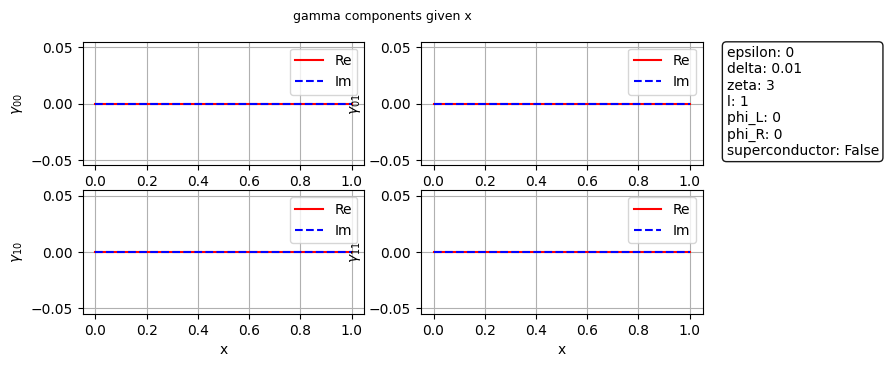

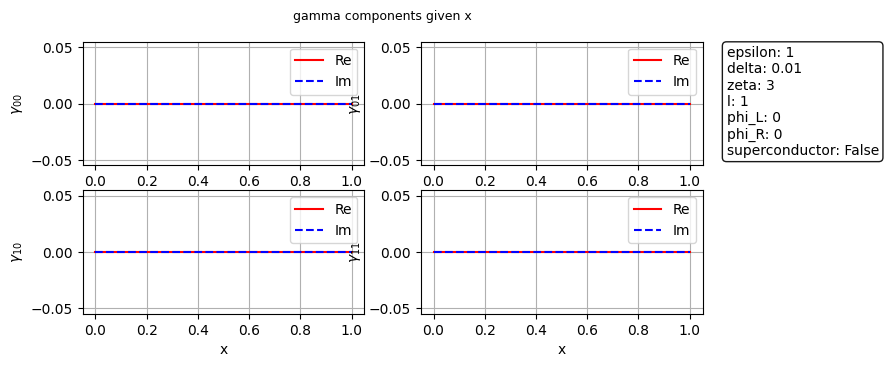

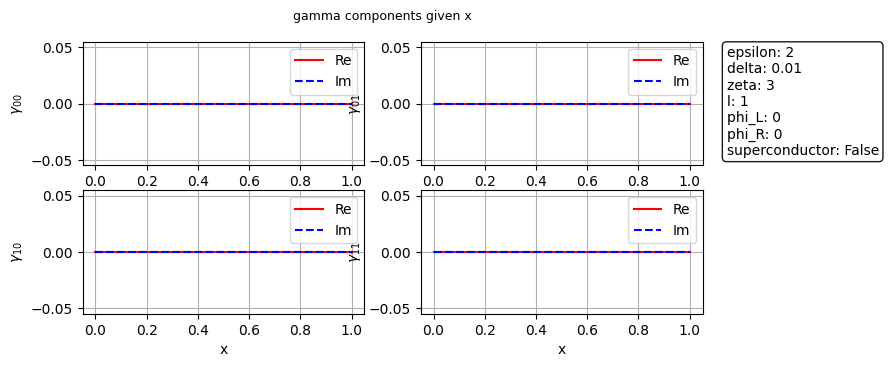

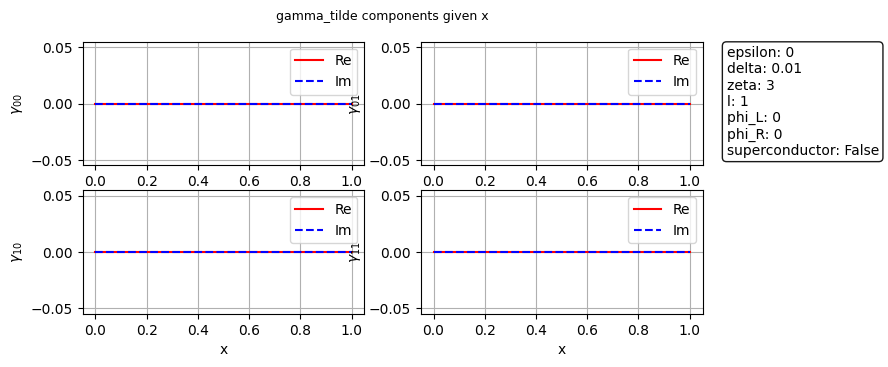

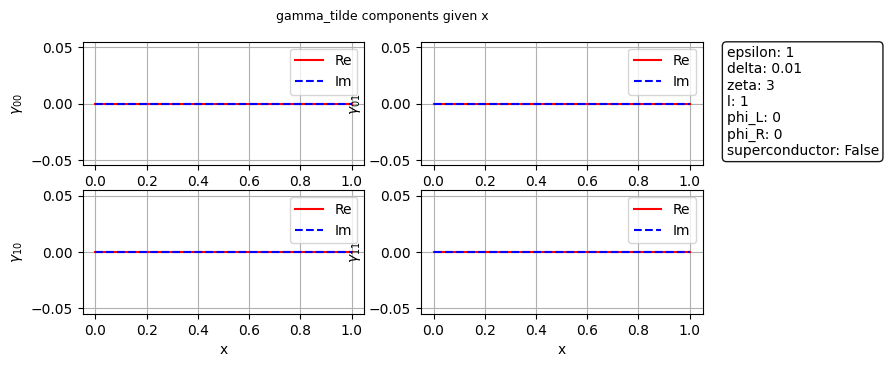

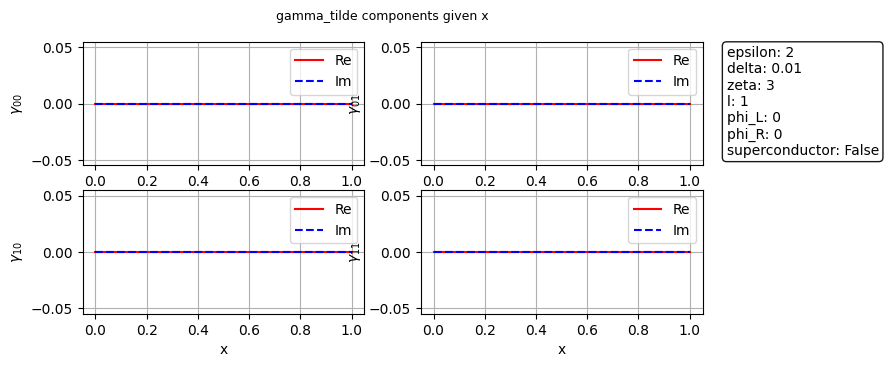

In [28]:
eps_arr_2g = np.array([0, 1, 2])

x = np.linspace(0, l, m)
y = np.zeros((32, m)) 
    
for epsilon in eps_arr_2g:
    plot_usadel_sol(
        x,
        y,
        epsilon,
        delta,
        zeta,
        l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
        matrix_label = 'gamma',
    )

for epsilon in eps_arr_2g:
    plot_usadel_sol(
        x,
        y,
        epsilon,
        delta,
        zeta,
        l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
        matrix_label = 'gamma_tilde',
)

#### h)

In [29]:
def rho_3_fun(matrix_shape: tuple[int, ...] = (2, 2)) -> npt.NDArray[np.complex128]: 
    """Calculates the Pauli-z in nambu space

    Args:
        matrix_shape (tuple[int, ...], optional): shape of I matrix, should always be 2x2 for the pauli matrix. Defaults to (2, 2).

    Returns:
        npt.NDArray[np.complex128]: Pauli-z in nambu space
    """
    I = np.eye(matrix_shape[0], dtype = np.complex128)
    
    return np.block([[I, np.zeros_like(I)], [np.zeros_like(I), -I]])

def green_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
)->  npt.NDArray[np.complex128]:
    """Calculates Green function

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Returns:
        npt.NDArray[np.complex128]: Green function
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)
    single = gamma.ndim == 2

    if single:
        I = np.eye(2, dtype=np.complex128)
        return np.block([
            [2*N - I, bmm(2 * N, gamma)],
            [bmm(-2 * N_tilde, gamma_tilde), -2*N_tilde + I]
        ])
    else:
        N_x = gamma.shape[-1]
        I = np.eye(2, dtype=np.complex128)[..., np.newaxis] * np.ones(N_x)

        first_row = np.concatenate([2*N - I, 2*bmm(N, gamma)], axis=1)
        second_row = np.concatenate([-2*bmm(N_tilde, gamma_tilde), -2*N_tilde + I], axis=1)

        return np.concatenate([first_row, second_row], axis=0)

def dos_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
) -> np.float64 | npt.NDArray[np.float64]:
    """Calculates density of states for Riccati amplitudes

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude

    Returns:
        np.float64: density of states
    """
    rho_3 = rho_3_fun()
    greens = green_fun(gamma, gamma_tilde)

    return np.real(tr(bmm(rho_3, greens))) / 4

Vi introduserer og bruker følgende plot funksjon i senere oppgaver. Vi kunne også brukt den i k) og l), men da får vi ikke samme plots i samme figur, som kan være ønskelig. Vi konkluderte med at en slik modifikasjon på plot_observable funksjonen gjør den unødvendig komplisert og fjerner simpelheten i anvendelse som var formålet. Derfor lagde vi egne scripts der vi ønsket flere plots i samme figur. 


Originalt lagret plot funksjonene plot_observable og plot_usadel til filer, som dere kan se i usadel/plot.py funksjonene i github, vi modifiserte nå til å vise plot i notebooken istedenfor.  Vi får noen feilmeldinger i plot_observable siden den bruker funksjonene current_integrand_fun som blir definert senere i notebooken, men den kjører fortsatt som den skal. Dette var ikke et problem i den originale strukturen, siden alt var definert og impotert fra ulike filer. I notebooken som skulle leveres fikk vi med oss at det var ønskelig at alle oppgaver skulle skrives i riktig rekkefølge, og har derfor definert plottefunksjonen en her, og current_integrand_fun senere, uten at dette blir noe problem for kjøringen.

Det ble brukt LLM CodeX til formatering av tekstboksen i plottene, og dette er markert med

#codex 

kode lagd med CodeX

#codex

In [34]:
def plot_observable(
    observable: Literal['dos', 'current', 'current_integrand'],
    variable_plot: Literal['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R'],
    x: npt.NDArray[np.float64],
    x_index : int,
    y: npt.NDArray[np.float64],
    epsilon: float | npt.NDArray[np.float64],
    delta: float | npt.NDArray[np.float64],
    zeta: float | npt.NDArray[np.float64],
    l: float | npt.NDArray[np.float64],
    phi_L: float | npt.NDArray[np.float64],
    phi_R: float | npt.NDArray[np.float64],
    superconductor: bool,
    figsize: tuple[int, ...] = (8,4),
):
    """Plots observable as function of variable_plot

    Args:
        observable (Literal['dos', 'current', 'current_integrand']): observable to plot
        variable_plot (Literal['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R']): value to plot observable over
        x (npt.NDArray[np.float64]): array to find solution
        x_index (int): index of which to evaluate observable if variable_Plot != 'x'
        location of which to evaluate solution, can be any integer if variable_plot == 'x'
        y (npt.NDARray[np.float64]): initial guess guess
        epsilon (float): quasiparticle excitation energy
        delta (float:) imaginary energy shift
        zeta (float): interface parameter
        l (float): length of normal region
        phi_L (float): left superconducting phase.
        phi_R (float): right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors
        matrix_label (str): which matrix to plot, can be 'gamma', 'gamma_tilde', 'w', 'w_tilde'
        figsize (tuple[int, ...], optional): desired figure size. Defaults to (8,4).

    Raises:
        ValueError: if observable not amongst 'docs', 'current', 'current_integrand'
        ValueError: if variable_plot not amongst 'x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R'
        ValueError: if (variable_plot == 'epsilon') and observable == 'current'
    """
    if observable not in ['dos', 'current', 'current_integrand']:
        raise ValueError("observable must be 'dos', 'current', or 'current_integrand'")
    
    if variable_plot not in ['x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L', 'phi_R']:
        raise ValueError("variable_plot must be 'x', 'epsilon', 'delta', 'zeta', 'l', 'phi_L' or 'phi_R'")
    
    if variable_plot == 'epsilon' and observable == 'current':
        raise ValueError("variable_plot == 'epsilon' and observable == 'current' is meaningless combination")
    
    variables = {
        'x': x,
        'y': y,
        'epsilon': epsilon,
        'delta': delta,
        'zeta': zeta,
        'l': l,
        'phi_L': phi_L,
        'phi_R': phi_R,
        'superconductor': superconductor
    }
    
    dynamic_var = variables[variable_plot]
    fixed_vars = {k: v for k, v in variables.items() if k!= variable_plot}
    
    if variable_plot == 'x':
        gamma, gamma_tilde, w, w_tilde, _ = usadel_solver(**variables)

        gamma = np.moveaxis(gamma, 0, -1)
        gamma_tilde = np.moveaxis(gamma_tilde, 0, -1)
        w = np.moveaxis(w, 0, -1)
        w_tilde = np.moveaxis(w_tilde, 0, -1)
        
        x_vals = x
        y_vals = np.zeros(len(x), dtype = np.float64)
        
        if observable == 'dos':
            y_vals = dos_fun(gamma, gamma_tilde)
            
        elif observable == 'current_integrand':
            y_vals = current_integrand_fun(gamma, gamma_tilde, w, w_tilde)
        
        elif observable == 'current':
            epsilon_vals = np.linspace(2.0, 0.0, 101)
            integrand_vals = np.zeros((epsilon_vals.size, x.size), dtype = np.float64)         

            y_current = y.copy()
    
            for j, epsilon_val in enumerate(epsilon_vals):
                epsilon_vars = variables | {'epsilon': epsilon_val, 'y': y_current}
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**epsilon_vars)
                    
                y_current = sol
                
                gamma_b = np.moveaxis(gamma, 0, -1)
                gamma_tilde_b = np.moveaxis(gamma_tilde, 0, -1)
                w_b = np.moveaxis(w, 0, -1)
                w_tilde_b = np.moveaxis(w_tilde, 0, -1)
                    
                integrand_vals[j] = current_integrand_fun(
                    gamma_b,
                    gamma_tilde_b,
                    w_b,
                    w_tilde_b
                )
            
            y_vals = - simpson(np.flip(integrand_vals, axis = 0), x = np.flip(epsilon_vals), axis = 0)
            
    else:
        dynamic_vals = np.array(dynamic_var, dtype = np.float64)
            
        x_vals = dynamic_var
        y_vals = np.zeros(len(x_vals), dtype = np.float64)
        
        y_current = y.copy()
        
        for i, value in enumerate(dynamic_vals):
            current_vars = fixed_vars | {variable_plot: value}

            if observable == 'dos':
                if variable_plot == 'epsilon':
                    current_vars['y'] = y_current
                
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**current_vars)
                
                if variable_plot == 'epsilon':
                    y_current = sol
                    
                y_vals[i] = dos_fun(
                    gamma[x_index],
                    gamma_tilde[x_index],
                )
                
            elif observable == 'current_integrand':
                if variable_plot == 'epsilon':
                    current_vars['y'] = y_current
                
                gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**current_vars)
                
                if variable_plot == 'epsilon':
                    y_current = sol
                
                y_vals[i] = current_integrand_fun(
                    gamma[x_index],
                    gamma_tilde[x_index],
                    w[x_index],
                    w_tilde[x_index]
                )    
                
            elif observable == 'current':
                epsilon_vals = np.linspace(2.0, 0.0, 101)
                integrand_vals = np.zeros_like(epsilon_vals)
                y_current = y.copy()    
                
                for j, epsilon_val in enumerate(epsilon_vals):
                    epsilon_vars = current_vars | {'epsilon': epsilon_val, 'y': y_current}
                    gamma, gamma_tilde, w, w_tilde, sol = usadel_solver(**epsilon_vars)
                    
                    y_current = sol
                    
                    integrand_vals[j] = current_integrand_fun(
                        gamma[x_index],
                        gamma_tilde[x_index],
                        w[x_index],
                        w_tilde[x_index]
                    )
                    
                y_vals[i] = -simpson(np.flip(integrand_vals), x = np.flip(epsilon_vals))
                    
    fig, ax = plt.subplots(figsize = figsize)
    ax.plot(x_vals, y_vals)
    
    if variable_plot == 'x':
        ax.set_title(f"{observable} given {variable_plot}")
    else:
        ax.set_title(f"{observable} given {variable_plot} at x_index = {x_index}")
        
    ax.set_xlabel(variable_plot)
    ax.set_ylabel(observable)
    ax.grid()
    
    param_text = '\n'.join(f'{k}: {v}' for k, v in fixed_vars.items() if k not in {'x', 'y'})
    
    #codex
    fig.subplots_adjust(bottom=0.22, top=0.90)
    
    fig.text(
        0.93,
        0.75,
        param_text,
        fontsize = 10,
        va = 'center',
        ha = 'left',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
    )
    #codex
    
    plt.show()

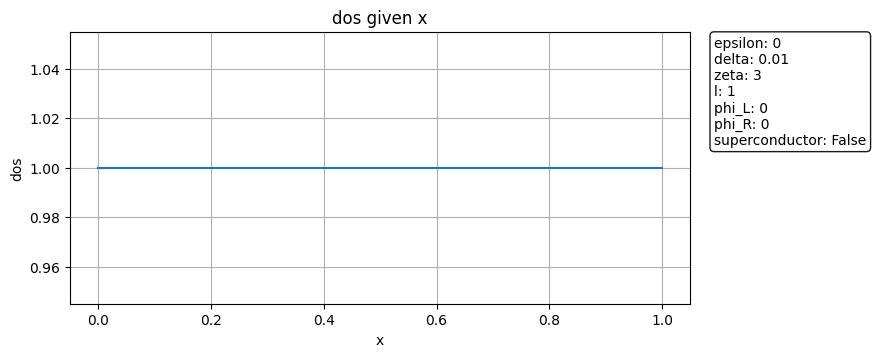

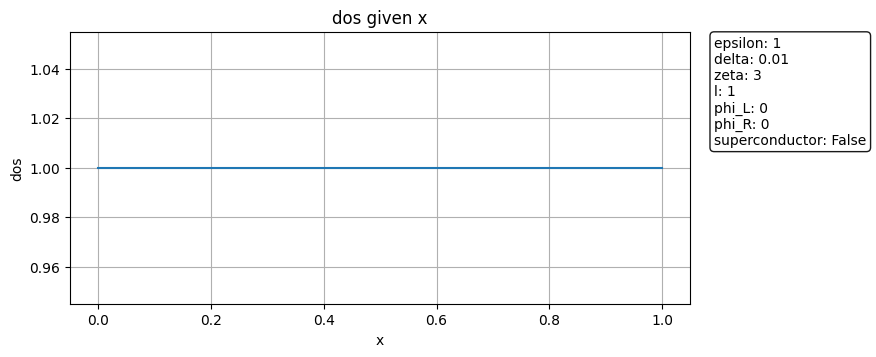

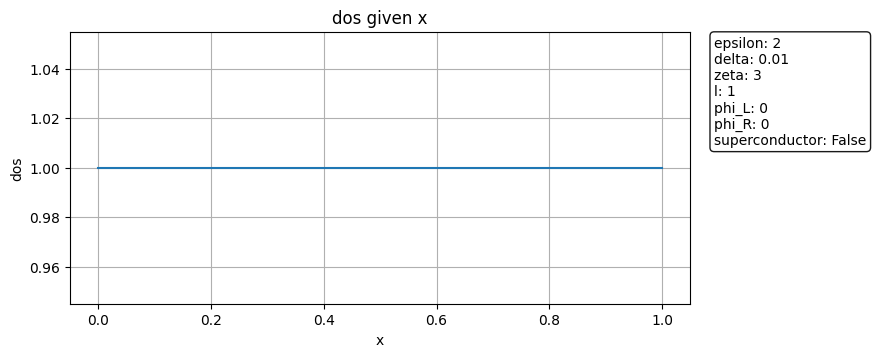

In [35]:
eps_arr_2h = np.array([0, 1, 2])
    
     
for epsilon in eps_arr_2h:
    plot_observable(
        observable = 'dos',
        variable_plot = 'x',
        x = x,
        x_index = -1,
        y = y,
        epsilon = epsilon,
        delta = delta,
        zeta = zeta,
        l = l,
        phi_L = 0,
        phi_R = 0,
        superconductor = False,
    )

#### j)

In [16]:
def usadel_solver(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    epsilon: float,
    delta: float,
    zeta: float,
    l: float,
    phi_L: float,
    phi_R: float,
    superconductor: bool,
    ) -> tuple[
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
        npt.NDArray[np.complex128],
    ]:
    """Calcualtes the Riccati parameters for given x and y

    Args:
        x (np.NDArray[np.float64]): Array to find solution on
        y (np.NDARray[np.float64]): Initial guess
        epsilon (np.float): Quasiparticle excitation energy
        delta (np.float): Imaginary energy shift
        zeta (np.float): Interface parameter
        l (np.float): Length of normal region
        phi_L (float): Left superconducting phase.
        phi_R (float): Right superconducting phase.
        superconductor (bool): True if normal metal is interfaced with two superconductors

    Returns:
        tuple[npt.NDArray[
            np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            npt.NDArray[np.complex128],
            ]: Arrays of values for gamma, gamma_tilde, w, w_tilde arrays at all x positions, sol
    """
    solution = solve_bvp(
        make_diff_system(epsilon, delta),
        make_bc(epsilon, delta, zeta, l, phi_L, phi_R, superconductor),
        x, y
    )  
    
    sol = solution.sol(x)
    matrices = vec_to_usadel_matrix(sol)

    gamma_arr = np.moveaxis(matrices[0], -1, 0)
    gamma_tilde_arr = np.moveaxis(matrices[1], -1, 0)
    w_arr = np.moveaxis(matrices[2], -1, 0)
    w_tilde_arr = np.moveaxis(matrices[3], -1, 0)

    return gamma_arr, gamma_tilde_arr, w_arr, w_tilde_arr, sol

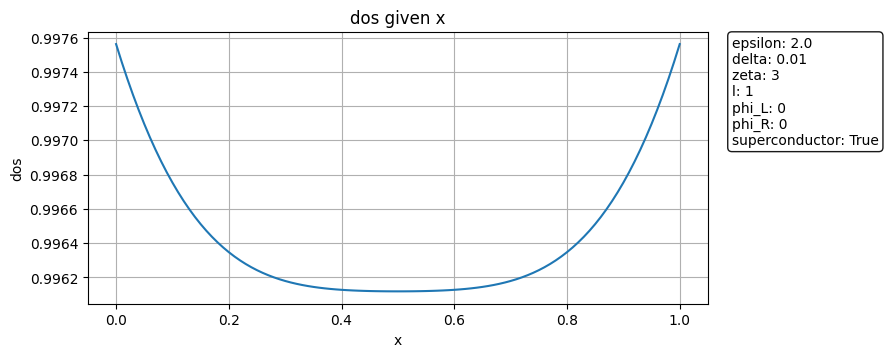

In [37]:
plot_observable(
        observable = 'dos',
        variable_plot = 'x',
        x = x,
        x_index = -1,
        y = y,
        epsilon = 2.0,
        delta = delta,
        zeta = zeta,
        l = l,
        phi_L = 0,
        phi_R = 0,
        superconductor = True,
    )
        

#### l)

In [17]:
def green_fun_deriv(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
) -> npt.NDArray[np.complex128]:
    """Calculates the derivative of the Green function

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        npt.NDArray[np.complex128]: d_x g
    """
    N, N_tilde = N_fun(gamma, gamma_tilde)
    d_N, d_N_tilde = N_deriv_fun(gamma, gamma_tilde, w, w_tilde)
    single = gamma.ndim == 2

    if single:
        return 2 * np.block([
            [d_N, bmm(N, w) + bmm(d_N, gamma)],
            [-bmm(N_tilde, w_tilde) - bmm(d_N_tilde, gamma_tilde), -d_N_tilde]
        ])
    else:
        first_row = np.concatenate([2*d_N, 2*(bmm(N, w) + bmm(d_N, gamma))], axis=1)
        second_row = np.concatenate([
            -2*(bmm(N_tilde, w_tilde) + bmm(d_N_tilde, gamma_tilde)),
            -2*d_N_tilde
        ], axis=1)

        return np.concatenate([first_row, second_row], axis=0)

def current_integrand_fun(
    gamma: npt.NDArray[np.complex128],
    gamma_tilde: npt.NDArray[np.complex128],
    w: npt.NDArray[np.complex128],
    w_tilde: npt.NDArray[np.complex128],
) -> np.float64 | npt.NDArray[np.float64]:
    """Calculates the current integrand

    Args:
        gamma (npt.NDArray[np.complex128]): Riccati amplitude
        gamma_tilde (npt.NDArray[np.complex128]): conjugate Riccati amplitude
        w (npt.NDArray[np.complex128]): d_x gamma
        w_tilde (npt.NDArray[np.complex128]): d_x gamma_tilde

    Returns:
        np.float64: current integrand
    """
    rho_3 = rho_3_fun()
    greens = green_fun(gamma, gamma_tilde)
    d_greens = green_fun_deriv(gamma, gamma_tilde, w, w_tilde)
    commutator = bmm(greens, d_greens) - bmm(d_greens, greens)
    
    return np.real(tr(bmm(rho_3, commutator)))

#### m)

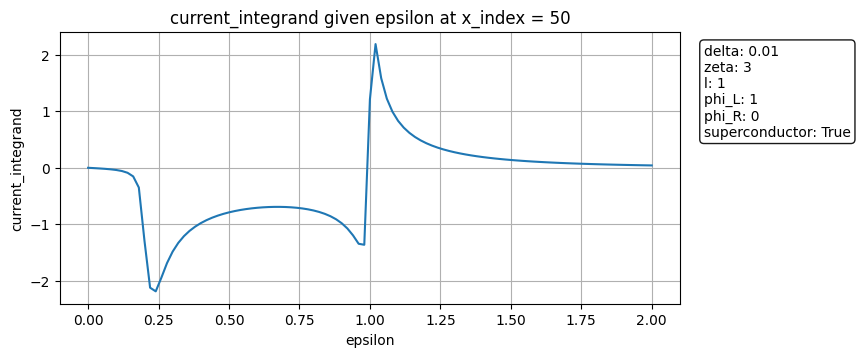

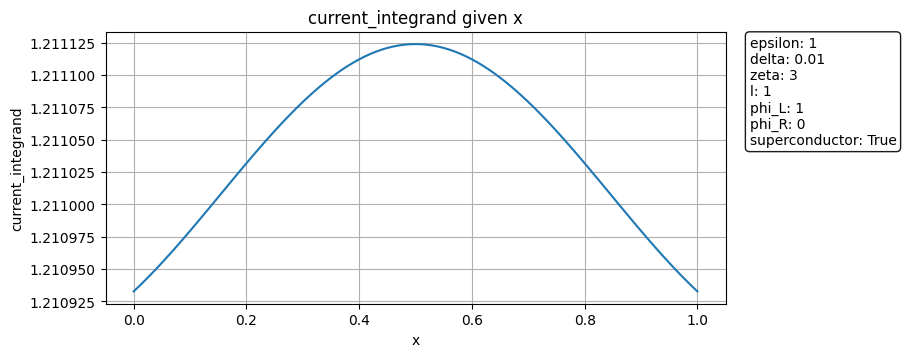

In [39]:
epsilon_arr = np.linspace(2, 0, 101)
x_index = len(x)//2
    
plot_observable(
    observable = 'current_integrand',
    variable_plot = 'epsilon',
    x = x,
    x_index = x_index,
    y = y,
    epsilon = epsilon_arr,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = 1,
    phi_R = 0,
    superconductor = True,
)

plot_observable(
    observable = 'current_integrand',
    variable_plot = 'x',
    x = x,
    x_index = 0,
    y = y,
    epsilon = 1,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = 1,
    phi_R = 0,
    superconductor = True,
)

#### n)

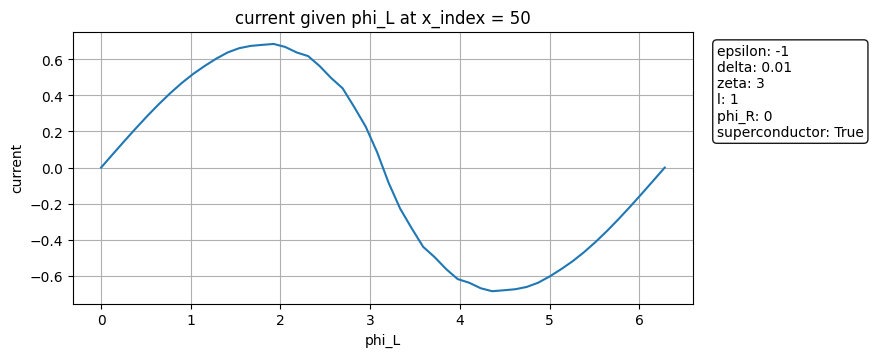

In [40]:
phi_L_arr_2n = np.linspace(0, 2 * np.pi, 50) #update to contain more points after optimizing runtime
x_index = len(x)//2
    
plot_observable(
    observable = 'current',
    variable_plot = 'phi_L',
    x = x,
    x_index = x_index,
    y = y,
    epsilon = -1,
    delta = delta,
    zeta = zeta,
    l = l,
    phi_L = phi_L_arr_2n,
    phi_R = 0,
    superconductor = True,
)